# 05 - Bootstrap, permutation and Bayesian analysis

**Goal:** confirm the retention result with three methods that rest on different
assumptions, and express it in decision-friendly Bayesian terms.

When methods built on different ideas agree, the conclusion is robust. Bayesian outputs
such as "probability gate_40 is better" and "expected loss" are also how many product
teams prefer to hear a result.

In [1]:
import pandas as pd                                        # tables
import numpy as np                                         # maths and random numbers
import matplotlib.pyplot as plt                            # charts
import seaborn as sns                                      # nicer charts
import time                                                # to measure how long loops take
from pathlib import Path                                   # file paths

sns.set_theme(style="whitegrid")                           # chart style
pd.set_option("display.max_columns", None)                 # never hide columns
pd.set_option("display.width", 200)                        # wide printing

In [2]:
ROOT = Path.cwd()                                          # folder the notebook runs in
if ROOT.name == "notebooks":                               # if inside notebooks/...
    ROOT = ROOT.parent                                     # ...go up to the project root
FIG_DIR = ROOT / "reports" / "figures"                     # charts folder
df = pd.read_csv(ROOT / "data" / "processed" / "cookie_cats_clean.csv")   # cleaned data
control_d7 = df.loc[df["version"] == "gate_30", "retention_7"].to_numpy().astype(np.int8)   # control D7 as 0/1 numbers
treat_d7 = df.loc[df["version"] == "gate_40", "retention_7"].to_numpy().astype(np.int8)     # treatment D7 as 0/1 numbers
control_d1 = df.loc[df["version"] == "gate_30", "retention_1"].to_numpy().astype(np.int8)   # control D1 as 0/1 numbers
treat_d1 = df.loc[df["version"] == "gate_40", "retention_1"].to_numpy().astype(np.int8)     # treatment D1 as 0/1 numbers
observed_diff_d7 = treat_d7.mean() - control_d7.mean()     # observed D7 difference (treatment minus control)
observed_diff_d1 = treat_d1.mean() - control_d1.mean()     # observed D1 difference
print("Observed D7 diff (pp):", round(100 * observed_diff_d7, 4))   # expect about -0.82
print("Observed D1 diff (pp):", round(100 * observed_diff_d1, 4))   # expect about -0.59

Observed D7 diff (pp): -0.8201
Observed D1 diff (pp): -0.5905


**Checkpoint:** D7 diff -0.8201 pp, D1 diff -0.5905 pp - the same numbers notebook 04 produced.

## Bootstrap

Each resample draws players from a group **with replacement**, so some players appear twice
and others not at all. The resamples imitate "what if the same experiment had run again with
a different set of similar players?"

In [3]:
rng = np.random.default_rng(seed=42)                       # random number generator with a fixed seed so results repeat exactly
n_boot = 10000                                             # number of bootstrap resamples
boot_control_d7 = np.empty(n_boot)                         # empty arrays to store each resample's result
boot_treat_d7 = np.empty(n_boot)
boot_diff_d7 = np.empty(n_boot)
boot_diff_d1 = np.empty(n_boot)
start = time.time()                                        # start a timer
for i in range(n_boot):                                    # one loop, one resample per iteration
    sample_c7 = rng.choice(control_d7, size=control_d7.size, replace=True)   # resample control D7 values with replacement
    sample_t7 = rng.choice(treat_d7, size=treat_d7.size, replace=True)       # resample treatment D7 values
    sample_c1 = rng.choice(control_d1, size=control_d1.size, replace=True)   # resample control D1 values
    sample_t1 = rng.choice(treat_d1, size=treat_d1.size, replace=True)       # resample treatment D1 values
    boot_control_d7[i] = sample_c7.mean()                  # control D7 rate in this resample
    boot_treat_d7[i] = sample_t7.mean()                    # treatment D7 rate in this resample
    boot_diff_d7[i] = sample_t7.mean() - sample_c7.mean()  # D7 difference in this resample
    boot_diff_d1[i] = sample_t1.mean() - sample_c1.mean()  # D1 difference in this resample
print("Bootstrap seconds:", round(time.time() - start, 1)) # how long the loop took

Bootstrap seconds: 7.0


In [4]:
boot_summary = pd.DataFrame({                              # build a small results table
    "metric": ["D1 retention", "D7 retention"],
    "observed_diff_pp": [100 * observed_diff_d1, 100 * observed_diff_d7],
    "boot_ci_low_pp": [100 * np.percentile(boot_diff_d1, 2.5), 100 * np.percentile(boot_diff_d7, 2.5)],     # 2.5th percentile
    "boot_ci_high_pp": [100 * np.percentile(boot_diff_d1, 97.5), 100 * np.percentile(boot_diff_d7, 97.5)],  # 97.5th percentile
    "share_resamples_gate30_better": [np.mean(boot_diff_d1 < 0), np.mean(boot_diff_d7 < 0)],                # how often control came out ahead
})
print(boot_summary.round(4))                               # show the table

         metric  observed_diff_pp  boot_ci_low_pp  boot_ci_high_pp  share_resamples_gate30_better
0  D1 retention           -0.5905         -1.2268           0.0621                         0.9609
1  D7 retention           -0.8201         -1.3425          -0.3125                         0.9994


**Checkpoint**

| Metric | Bootstrap 95% CI (pp) | Share of resamples where gate_30 was better |
|---|---|---|
| D1 | -1.227 to +0.062 | 0.961 |
| D7 | -1.343 to -0.313 | 0.999 |

The bootstrap intervals land almost exactly on the formula-based intervals from notebook 04,
without using any formula at all. With samples this large the normal approximation works very
well - and now that is demonstrated rather than assumed.

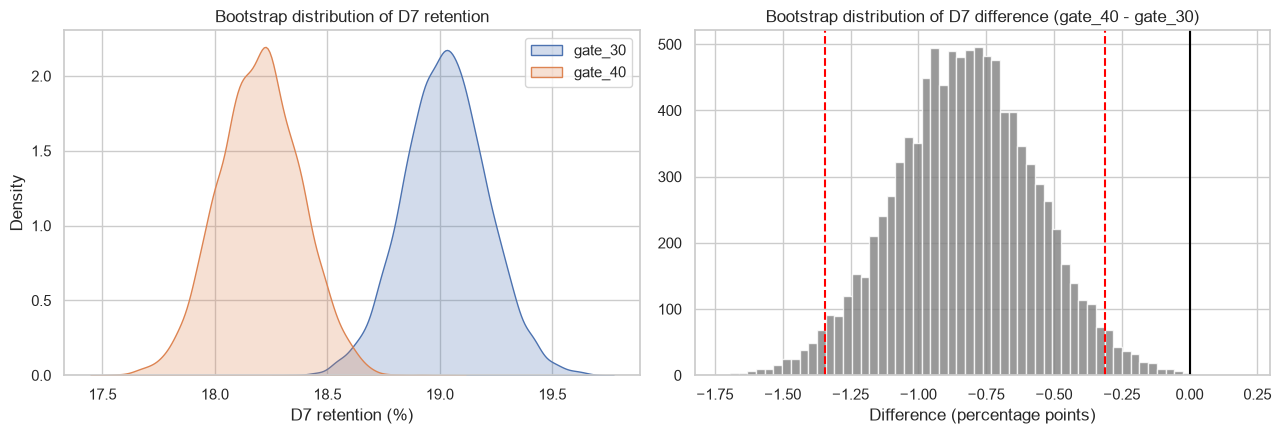

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))          # two charts side by side
sns.kdeplot(x=100 * boot_control_d7, label="gate_30", fill=True, ax=axes[0])   # smoothed distribution of control D7
sns.kdeplot(x=100 * boot_treat_d7, label="gate_40", fill=True, ax=axes[0])     # smoothed distribution of treatment D7
axes[0].set_title("Bootstrap distribution of D7 retention")                    # left title
axes[0].set_xlabel("D7 retention (%)")                                         # left x label
axes[0].legend()                                                               # show the legend
axes[1].hist(100 * boot_diff_d7, bins=60, color="grey", alpha=0.8)             # histogram of the differences
axes[1].axvline(100 * np.percentile(boot_diff_d7, 2.5), color="red", linestyle="--")    # lower CI bound
axes[1].axvline(100 * np.percentile(boot_diff_d7, 97.5), color="red", linestyle="--")   # upper CI bound
axes[1].axvline(0, color="black")                                              # zero = no difference
axes[1].set_title("Bootstrap distribution of D7 difference (gate_40 - gate_30)")   # right title
axes[1].set_xlabel("Difference (percentage points)")                           # right x label
fig.tight_layout()                                                             # tidy
fig.savefig(FIG_DIR / "06_bootstrap_d7.png", dpi=150)                          # save
plt.show()                                                                     # display

## Permutation test

Shuffling the group labels creates worlds in which the gate truly does nothing. If the real
difference is rarer than almost every shuffled difference, chance is an unlikely explanation.

In [6]:
rng_perm = np.random.default_rng(seed=2024)                # a separate generator so this cell gives the same result every run
all_d7 = np.concatenate([control_d7, treat_d7])            # put every player's D7 value in one array
n_control = control_d7.size                                # the first n_control positions will play "control"
n_perm = 10000                                             # number of shuffles
perm_diffs = np.empty(n_perm)                              # array to store each shuffle's difference
start = time.time()                                        # timer
for i in range(n_perm):                                    # one loop, one shuffle per iteration
    shuffled = rng_perm.permutation(all_d7)                # randomly reorder players, which breaks any link to their real group
    perm_diffs[i] = shuffled[n_control:].mean() - shuffled[:n_control].mean()   # fake treatment minus fake control
print("Permutation seconds:", round(time.time() - start, 1))              # timing
perm_p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff_d7))       # share of shuffles at least as extreme as what we observed
mc_standard_error = np.sqrt(perm_p_value * (1 - perm_p_value) / n_perm)   # simulation noise in that estimate
print("Permutation p-value (D7):", perm_p_value, "+/-", round(mc_standard_error, 5))   # small p-values from 10,000 shuffles are noisy

Permutation seconds: 12.5
Permutation p-value (D7): 0.0016 +/- 0.0004


**Checkpoint:** a p-value of about 0.0016 with a simulation error of about 0.0004.

With 10,000 shuffles a small p-value carries real simulation noise, so it is reported with
its margin. A different seed can give 0.0013 or 0.0019, and that is expected.

In [7]:
total_players = all_d7.size                                # all players
total_retained = int(all_d7.sum())                         # all D7-retained players
n_treat = treat_d7.size                                    # size of the fake treatment group
retained_in_fake_treat = rng_perm.hypergeometric(ngood=total_retained, nbad=total_players - total_retained, nsample=n_treat, size=2000000)  # retained players landing in fake treatment per shuffle
fast_diffs = retained_in_fake_treat / n_treat - (total_retained - retained_in_fake_treat) / n_control   # fake treatment rate minus fake control rate
exact_p_value = np.mean(np.abs(fast_diffs) >= abs(observed_diff_d7) - 1e-12)   # tiny tolerance avoids floating-point rounding issues
print("Permutation p-value from 2,000,000 shuffles:", round(exact_p_value, 5))  # should be very close to the z-test p-value

Permutation p-value from 2,000,000 shuffles: 0.00162


**Checkpoint:** about 0.00162, almost identical to the z-test p-value of 0.00155.

Shuffling labels only changes how many retained players land in each group, and that count
follows a hypergeometric distribution. Drawing from it directly simulates two million shuffles
in about a second instead of reordering 90,189 values ten thousand times.

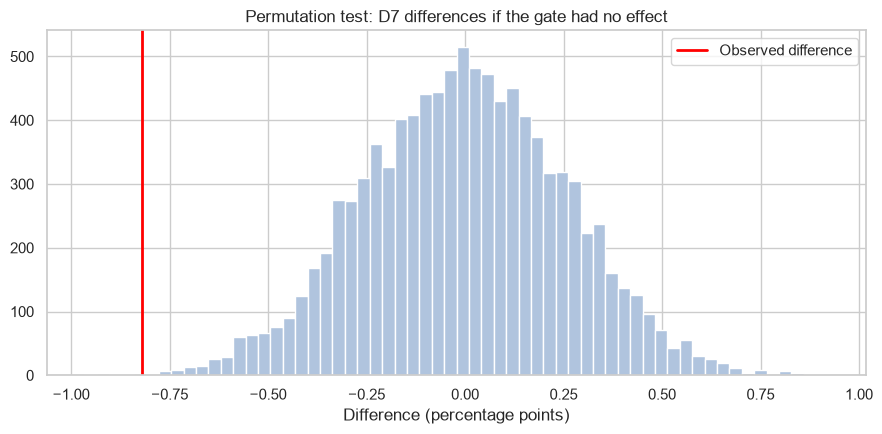

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))                   # empty chart
ax.hist(100 * perm_diffs, bins=60, color="lightsteelblue") # differences we get when the label means nothing
ax.axvline(100 * observed_diff_d7, color="red", linewidth=2, label="Observed difference")   # the real result
ax.set_title("Permutation test: D7 differences if the gate had no effect")                  # title
ax.set_xlabel("Difference (percentage points)")            # x label
ax.legend()                                                # legend
fig.tight_layout()                                         # tidy
fig.savefig(FIG_DIR / "07_permutation_d7.png", dpi=150)    # save
plt.show()                                                 # display

## Bayesian Beta-Binomial analysis

A Beta(1, 1) prior treats every retention rate from 0% to 100% as equally plausible before
seeing data. Updating it with the observed counts gives a posterior distribution for each
group, and the difference between posterior draws answers business questions directly.

In [9]:
rng_bayes = np.random.default_rng(seed=7)                  # separate generator for the Bayesian draws
prior_a = 1                                                # Beta(1, 1) prior = every retention rate equally likely before seeing data
prior_b = 1
n_draws = 200000                                           # number of posterior samples
bayes_rows = []                                            # list to collect results
for metric, c_arr, t_arr in [("D1 retention", control_d1, treat_d1), ("D7 retention", control_d7, treat_d7)]:   # loop over metrics
    post_control = rng_bayes.beta(prior_a + c_arr.sum(), prior_b + c_arr.size - c_arr.sum(), size=n_draws)   # posterior draws for control rate
    post_treat = rng_bayes.beta(prior_a + t_arr.sum(), prior_b + t_arr.size - t_arr.sum(), size=n_draws)     # posterior draws for treatment rate
    post_diff = post_treat - post_control                  # posterior draws of the difference
    bayes_rows.append({                                    # store the summary for this metric
        "metric": metric,
        "prob_gate40_better": np.mean(post_diff > 0),                                 # chance gate_40 truly has higher retention
        "expected_loss_choose_gate40_pp": 100 * np.mean(np.maximum(-post_diff, 0)),   # average retention lost if we pick gate_40 and it is worse
        "expected_loss_choose_gate30_pp": 100 * np.mean(np.maximum(post_diff, 0)),    # average retention lost if we keep gate_30 and it is worse
        "credible_low_pp": 100 * np.percentile(post_diff, 2.5),                       # 95% credible interval lower end
        "credible_high_pp": 100 * np.percentile(post_diff, 97.5),                     # 95% credible interval upper end
    })
    if metric == "D7 retention":                           # keep D7 draws for the chart below
        d7_post_control = post_control
        d7_post_treat = post_treat
bayes_df = pd.DataFrame(bayes_rows)                        # results table
print(bayes_df.round(4))                                   # show

         metric  prob_gate40_better  expected_loss_choose_gate40_pp  expected_loss_choose_gate30_pp  credible_low_pp  credible_high_pp
0  D1 retention              0.0366                          0.5952                          0.0048          -1.2350            0.0559
1  D7 retention              0.0009                          0.8211                          0.0001          -1.3304           -0.3136


**Checkpoint**

| Metric | P(gate_40 better) | Expected loss if you ship gate_40 | Expected loss if you keep gate_30 | 95% credible interval (pp) |
|---|---|---|---|---|
| D1 | about 0.037 | about 0.595 pp | about 0.005 pp | -1.235 to +0.056 |
| D7 | about 0.001 | about 0.821 pp | about 0.000 pp | -1.330 to -0.314 |

- **The probability that gate_40 is better on D7 is about 0.1%.** That is the direct statement
  people often think a p-value makes, and only a Bayesian model actually makes it.
- **Expected loss.** Shipping gate_40 costs about 0.82 pp of D7 retention on average if the
  choice is wrong, while keeping gate_30 costs almost nothing. That asymmetry makes the
  decision easy.
- **Credible vs confidence interval.** A credible interval says "given the data and prior, there
  is a 95% probability the true difference lies in this range". With a flat prior and this much
  data it lands on top of the confidence interval.

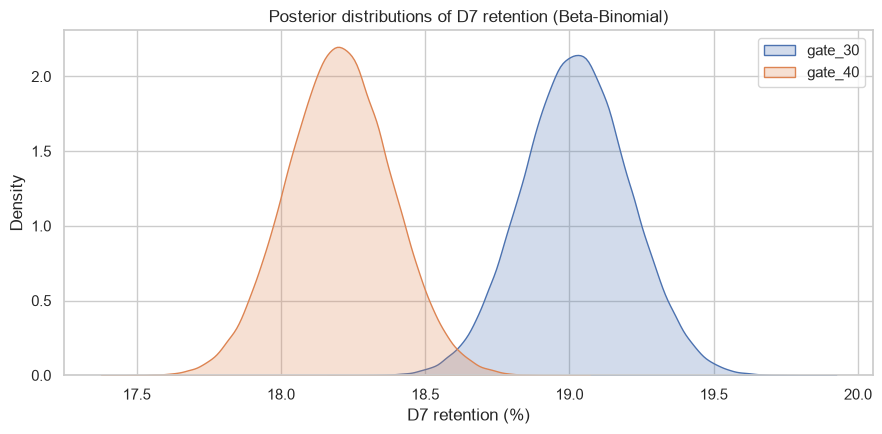

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))                   # empty chart
sns.kdeplot(x=100 * d7_post_control, fill=True, label="gate_30", ax=ax)   # control posterior
sns.kdeplot(x=100 * d7_post_treat, fill=True, label="gate_40", ax=ax)     # treatment posterior
ax.set_title("Posterior distributions of D7 retention (Beta-Binomial)")   # title
ax.set_xlabel("D7 retention (%)")                          # x label
ax.legend()                                                # legend
fig.tight_layout()                                         # tidy
fig.savefig(FIG_DIR / "08_bayes_posterior_d7.png", dpi=150)   # save
plt.show()                                                 # display

In [11]:
boot_summary.to_csv(ROOT / "data" / "processed" / "bootstrap_results.csv", index=False)   # bootstrap table
bayes_df.to_csv(ROOT / "data" / "processed" / "bayesian_results.csv", index=False)        # Bayesian table
print("Saved bootstrap and Bayesian results")              # confirm

Saved bootstrap and Bayesian results
